<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/narmax_example_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NARX example: 1/4 drone

NARX model for the 1/4 drone dataset.

## Imports, functions, and classes

In [ ]:
import numpy as np
from itertools import combinations_with_replacement
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import scipy.io
import numpy as np

# --- Function: regMatARX ---
def regMatARX(y_signal_in,
              u_signal_in,
              ny: int,
              nu: int):
    """
    Creates the initial ARX regression matrix and the target vector y(k).
    AR (y-lag) terms are NOT negated.

    Args:
        y_signal_in (array-like): Output data vector.
        u_signal_in (array-like): Input data vector.
        ny (int): Number of past y lags (autoregressive order).
        nu (int): Number of past u lags (exogenous input order).

    Returns:
        P0_data (np.ndarray): The ARX regressor matrix. Shape (NP, ny + nu).
        P0_colnames (list): Column names for P0_data.
        y_target (np.ndarray): The target vector y(k). Shape (NP,).
    """
    if not isinstance(y_signal_in, np.ndarray):
        y_signal = np.array(y_signal_in, dtype=float)
    else:
        y_signal = y_signal_in.astype(float)

    if not isinstance(u_signal_in, np.ndarray):
        u_signal = np.array(u_signal_in, dtype=float)
    else:
        u_signal = u_signal_in.astype(float)

    if len(y_signal) != len(u_signal):
        raise ValueError("Input signals y_signal and u_signal must have the same length.")
    if ny < 0 or nu < 0:
        raise ValueError("Lags ny and nu must be non-negative.")

    N_total_samples = len(y_signal)

    max_lag = 0
    if ny > 0: max_lag = max(max_lag, ny)
    if nu > 0: max_lag = max(max_lag, nu)

    y_target = y_signal[max_lag:]
    num_effective_rows = len(y_target)

    P0_colnames = []
    if ny > 0: P0_colnames.extend([f'y(k-{i})' for i in range(1, ny + 1)])
    if nu > 0: P0_colnames.extend([f'u(k-{i})' for i in range(1, nu + 1)])
    num_P0_cols = len(P0_colnames)

    if num_effective_rows == 0:
        return np.empty((0, num_P0_cols), dtype=float), P0_colnames, np.empty((0,), dtype=float)

    P0_rows_list = []
    for k_target_idx in range(max_lag, N_total_samples):
        current_regressor_row = []
        for j_lag_idx in range(1, ny + 1):
            current_regressor_row.append(y_signal[k_target_idx - j_lag_idx])
        for j_lag_idx in range(1, nu + 1):
            current_regressor_row.append(u_signal[k_target_idx - j_lag_idx])
        P0_rows_list.append(current_regressor_row)
    P0_data = np.array(P0_rows_list, dtype=float)
    return P0_data, P0_colnames, y_target

# --- Function: regMatNARX ---
def regMatNARX(u_signal_in,
               y_signal_in,
               nu: int,
               ny: int,
               poly_order_l: int):
    """
    Generates the full candidate regression matrix for a NARX model
    and the corresponding target vector y(k).
    """
    if not isinstance(y_signal_in, np.ndarray): y_signal = np.array(y_signal_in, dtype=float)
    else: y_signal = y_signal_in.astype(float)
    if not isinstance(u_signal_in, np.ndarray): u_signal = np.array(u_signal_in, dtype=float)
    else: u_signal = u_signal_in.astype(float)

    if len(y_signal) != len(u_signal): raise ValueError("Signals must have same length.")
    if ny < 0 or nu < 0: raise ValueError("Lags must be non-negative.")
    if poly_order_l < 1: raise ValueError("Polynomial order l must be at least 1.")

    P0_data, P0_colnames, y_target = regMatARX(y_signal, u_signal, ny, nu)
    NP = len(y_target) # Number of effective rows (can be 0)

    if NP > 0:
        P_columns_list = [np.ones((NP, 1), dtype=float)] # Constant term
    else:
        P_columns_list = [np.empty((0, 1), dtype=float)] # Constant term for 0 rows

    P_final_colnames = ['constant']
    P_columns_list.append(P0_data)
    P_final_colnames.extend(P0_colnames)
    num_P0_base_regressors = P0_data.shape[1]

    if poly_order_l >= 2 and num_P0_base_regressors > 0:
        for current_poly_order in range(2, poly_order_l + 1):
            for col_indices_tuple in combinations_with_replacement(range(num_P0_base_regressors), current_poly_order):
                term_name = "".join([P0_colnames[i] for i in col_indices_tuple])
                P_final_colnames.append(term_name)
                if NP > 0: # Only compute values if there are rows
                    selected_P0_cols = P0_data[:, list(col_indices_tuple)]
                    new_poly_term_col = np.prod(selected_P0_cols, axis=1, keepdims=True)
                    P_columns_list.append(new_poly_term_col)
                # If NP=0, P_columns_list will keep (0,k) arrays, and P_final_colnames grows.
                # np.concatenate will correctly form a (0, total_cols) matrix.

    if NP == 0: # If no rows, ensure all appended arrays in P_columns_list are (0, N_cols)
        # P_columns_list might contain P0_data (0,k_P0) and constant (0,1).
        # Polynomial terms if poly_order_l >=2 are only added to P_final_colnames if NP=0.
        # We need to create empty columns for these polynomial terms if they were named.
        # Current P_columns_list: [(0,1)_const, (0,k_P0)_P0_data]
        # P_final_colnames: [const, P0_names..., Poly_names...]
        # We need to add empty columns for Poly_names to P_columns_list before concatenate.

        # Number of polynomial terms added only to colnames if NP=0:
        num_poly_terms_in_colnames = len(P_final_colnames) - len(P_columns_list[0].T) - P0_data.shape[1]

        # This is a bit tricky; let's simplify the construction of P_final_data
        # if NP == 0, it must be an empty matrix with the correct number of total columns.
        total_cols = len(P_final_colnames)
        P_final_data = np.empty((0, total_cols), dtype=float)
    else: # NP > 0
        P_final_data = np.concatenate(P_columns_list, axis=1)

    return P_final_data, P_final_colnames, y_target

# --- Function: frols_py ---
def frols_py(P_regressors, Y_target_in, selection_criteria, P_colnames=None, epsilon=1e-12):
    """
    Forward Orthogonal Least Squares algorithm for model term selection and parameter estimation.

    Args:
        P_regressors (np.ndarray): The candidate regressor matrix.
        Y_target_in (array-like): The target vector y(k).
        selection_criteria (float or int): If float in [0, 1], it's the ERR threshold.
                                            If integer > 1, it's the number of terms to select.
        P_colnames (list, optional): Column names for P_regressors. Defaults to None.
        epsilon (float, optional): Small value for numerical stability. Defaults to 1e-12.

    Returns:
        dict: Results dictionary including selected terms, parameters, ERR values, etc.
    """
    if Y_target_in.ndim == 1:
        Y_target = Y_target_in.reshape(-1, 1)
    else:
        Y_target = Y_target_in

    M = P_regressors.shape[1]
    NP = P_regressors.shape[0]
    empty_result = {
        'th': np.array([]), 'Psel_data': np.empty((NP,0)), 'Psel_colnames': [],
        'g': np.array([]), 'W': np.empty((NP,0)), 'A': np.empty((0,0)),
        'ERR_values': np.array([]), 'selected_indices': []}
    if NP == 0 or M == 0: return empty_result

    is_err_threshold = isinstance(selection_criteria, (float, np.floating)) and 0 <= selection_criteria <= 1
    if isinstance(selection_criteria, int):
        num_terms_to_select = selection_criteria
        if num_terms_to_select < 1:
             raise ValueError("Number of terms to select must be a positive integer.")
    elif not is_err_threshold:
        raise ValueError("selection_criteria must be a float in [0, 1] or an integer > 0.")


    sig_yy_val = (Y_target.T @ Y_target).item();
    if sig_yy_val < epsilon: sig_yy_val = epsilon

    selected_terms_indices = []; err_selected_list = []; g_selected_list = []
    Q_orthogonal_bases = np.empty((NP, 0)); A_matrix = np.empty((0,0))
    M0 = 0

    for s_term_iter in range(M):
        current_ERRs = np.full(M, -np.inf); current_gs = np.zeros(M)
        current_Qs_storage = np.zeros((NP, M))

        if s_term_iter == 0:
            for m_idx in range(M):
                p_m = P_regressors[:, m_idx:m_idx+1]; p_m_norm_sq = (p_m.T @ p_m).item()
                if p_m_norm_sq >= epsilon:
                    current_Qs_storage[:,m_idx] = p_m.flatten()
                    current_gs[m_idx] = (Y_target.T @ p_m).item() / p_m_norm_sq
                    current_ERRs[m_idx] = (current_gs[m_idx]**2 * p_m_norm_sq) / sig_yy_val
        else:
            for m_idx in range(M):
                if m_idx in selected_terms_indices: continue
                p_m = P_regressors[:, m_idx:m_idx+1]; q_m_orth = p_m.copy()
                for r_q_idx in range(M0):
                    q_r = Q_orthogonal_bases[:, r_q_idx:r_q_idx+1]; q_r_norm_sq = (q_r.T @ q_r).item()
                    alpha_mr = 0.0
                    if q_r_norm_sq >= epsilon: alpha_mr = (p_m.T @ q_r).item() / q_r_norm_sq
                    q_m_orth -= alpha_mr * q_r
                current_Qs_storage[:,m_idx] = q_m_orth.flatten()
                q_m_orth_norm_sq = (q_m_orth.T @ q_m_orth).item()
                if q_m_orth_norm_sq >= epsilon:
                    current_gs[m_idx] = (Y_target.T @ q_m_orth).item() / q_m_orth_norm_sq
                    current_ERRs[m_idx] = (current_gs[m_idx]**2 * q_m_orth_norm_sq) / sig_yy_val

        if np.all(np.isneginf(current_ERRs)): break
        newly_selected_idx = np.argmax(current_ERRs)
        selected_terms_indices.append(newly_selected_idx)
        err_selected_list.append(current_ERRs[newly_selected_idx])
        g_selected_list.append(current_gs[newly_selected_idx])
        Q_selected_term = current_Qs_storage[:, newly_selected_idx:newly_selected_idx+1]
        Q_orthogonal_bases = Q_selected_term if Q_orthogonal_bases.shape[1] == 0 else np.hstack((Q_orthogonal_bases, Q_selected_term))

        p_orig_new_sel = P_regressors[:, newly_selected_idx:newly_selected_idx+1]
        if M0 == 0: A_matrix = np.array([[1.0]])
        else:
            A_new_col = np.zeros((M0, 1))
            for r_A_idx in range(M0):
                q_r_for_A = Q_orthogonal_bases[:, r_A_idx:r_A_idx+1]
                q_r_for_A_norm_sq = (q_r_for_A.T @ q_r_for_A).item()
                if q_r_for_A_norm_sq >= epsilon:
                    A_new_col[r_A_idx, 0] = (p_orig_new_sel.T @ q_r_for_A).item() / q_r_for_A_norm_sq
            A_matrix = np.block([[A_matrix, A_new_col],[np.zeros((1, M0)), np.array([[1.0]])]])
        M0 += 1

        # Check selection criteria
        if is_err_threshold:
            if (1.0 - np.sum(err_selected_list)) <= selection_criteria:
                break
        else: # selection_criteria is an integer number of terms
            if M0 >= num_terms_to_select:
                break


    if M0 == 0: return empty_result
    A_final = A_matrix; g_final = np.array(g_selected_list).reshape(-1, 1)
    theta_FROLS = np.linalg.solve(A_final, g_final) if A_final.size > 0 and A_final.shape[0] == A_final.shape[1] else np.array([])
    if theta_FROLS.size == 0 and A_final.size > 0 : # If solve failed or matrix not square
        try: # Fallback for safety, though solve should work for well-formed A
            theta_FROLS = np.linalg.pinv(A_final) @ g_final
        except: # Catch all exceptions from pinv if A_final is really problematic
             theta_FROLS = np.array([])


    P_sel_data = P_regressors[:, selected_terms_indices]
    P_sel_colnames = [P_colnames[i] for i in selected_terms_indices] if P_colnames else []
    return {'th': theta_FROLS.flatten(), 'Psel_data': P_sel_data, 'Psel_colnames': P_sel_colnames,
            'g': g_final.flatten(), 'W': Q_orthogonal_bases, 'A': A_final,
            'ERR_values': np.array(err_selected_list).flatten(), 'selected_indices': selected_terms_indices}

# --- Class: NARX ---
class NARX:
    def __init__(self, nu: int, ny: int, poly_order_l: int, selection_criteria: float = 0.01):
        self.nu = nu
        self.ny = ny
        self.poly_order_l = poly_order_l
        self.selection_criteria = selection_criteria # Renamed from rho_threshold

        self.theta_ = None
        self.selected_P_colnames_ = None
        self.selected_indices_ = None
        self.P_candidate_colnames_ = None

        self._P0_colnames_base_ = []
        if self.ny > 0: self._P0_colnames_base_.extend([f'y(k-{i})' for i in range(1, self.ny + 1)])
        if self.nu > 0: self._P0_colnames_base_.extend([f'u(k-{i})' for i in range(1, self.nu + 1)])
        self._num_P0_base_regressors_ = len(self._P0_colnames_base_)
        self._max_lag_internal_ = max(self.ny, self.nu) if self.ny > 0 or self.nu > 0 else 0
        self.fit_results_ = None

    def fit(self, u_train, y_train):
        u_train_np = np.asarray(u_train, dtype=float)
        y_train_np = np.asarray(y_train, dtype=float)

        P_cand_matrix, self.P_candidate_colnames_, y_target_train = regMatNARX(
            u_train_np, y_train_np, self.nu, self.ny, self.poly_order_l
        )

        frols_results = frols_py(
            P_cand_matrix, y_target_train, self.selection_criteria, self.P_candidate_colnames_ # Pass selection_criteria
        )

        self.theta_ = frols_results['th']
        self.selected_P_colnames_ = frols_results['Psel_colnames']
        self.selected_indices_ = frols_results['selected_indices']
        self.fit_results_ = frols_results

        if self.theta_ is None or len(self.theta_) == 0:
            print("Warning: FROLS did not select any terms or failed to estimate parameters.")
        return self

    def _form_single_candidate_row_values(self, current_y_lags_list, current_u_lags_list):
        current_P0_values = []
        if self.ny > 0: current_P0_values.extend(current_y_lags_list)
        if self.nu > 0: current_P0_values.extend(current_u_lags_list)

        all_terms_this_row_dict = {'constant': 1.0}
        for i in range(self._num_P0_base_regressors_):
            all_terms_this_row_dict[self._P0_colnames_base_[i]] = current_P0_values[i]

        if self.poly_order_l >= 2 and self._num_P0_base_regressors_ > 0:
            for current_order_poly in range(2, self.poly_order_l + 1):
                for p0_indices_tuple in combinations_with_replacement(range(self._num_P0_base_regressors_), current_order_poly):
                    term_name = "".join([self._P0_colnames_base_[j] for j in p0_indices_tuple])
                    term_val = np.prod([current_P0_values[j] for j in p0_indices_tuple])
                    all_terms_this_row_dict[term_name] = term_val

        full_candidate_row_ordered_list = []
        if self.P_candidate_colnames_ is None:
            raise RuntimeError("P_candidate_colnames_ not set. Model might not be fitted correctly.")

        for name in self.P_candidate_colnames_:
            val = all_terms_this_row_dict.get(name)
            if val is None:
                print(f"Warning: Term '{name}' not found in generated row dict for FR prediction. Using 0.0. This may indicate an issue.")
                full_candidate_row_ordered_list.append(0.0)
            else:
                full_candidate_row_ordered_list.append(val)
        return np.array(full_candidate_row_ordered_list)

    def predict(self, u_inputs, y_history_for_lags_or_osa=None, mode='OSA'):
        if self.theta_ is None or len(self.theta_) == 0:
            raise RuntimeError("Model has not been fitted or no terms were selected. Call fit() first.")

        u_inputs_np = np.asarray(u_inputs, dtype=float)
        if y_history_for_lags_or_osa is not None:
            y_hist_np = np.asarray(y_history_for_lags_or_osa, dtype=float)

        if mode == 'OSA':
            if y_history_for_lags_or_osa is None:
                raise ValueError("For OSA prediction, y_history_for_lags_or_osa (actual y values) must be provided.")

            P_osa_full, P_osa_full_colnames, y_target_osa = regMatNARX(
                u_inputs_np, y_hist_np, self.nu, self.ny, self.poly_order_l
            )

            if P_osa_full.shape[0] == 0 :
                return np.array([]), y_target_osa

            if list(P_osa_full_colnames) != list(self.P_candidate_colnames_):
                 print("Warning: OSA prediction column names differ from training. This might lead to issues if order varies subtly.")

            P_selected_osa = P_osa_full[:, self.selected_indices_]
            y_hat_osa = P_selected_osa @ self.theta_
            return y_hat_osa, y_target_osa

        elif mode == 'FR':
            if y_history_for_lags_or_osa is None:
                raise ValueError("For FR simulation, y_history_for_lags_or_osa (initial y conditions) must be provided.")

            y_initial_conditions = y_hist_np

            if len(y_initial_conditions) < self._max_lag_internal_:
                raise ValueError(f"Not enough initial y conditions for FR. Need {self._max_lag_internal_}, got {len(y_initial_conditions)}")

            num_total_timeline_points = len(u_inputs_np)
            if num_total_timeline_points < self._max_lag_internal_ and self._max_lag_internal_ > 0 :
                 print("Warning: u_inputs not long enough for FR simulation start. Returning empty.")
                 return np.array([])

            y_hat_fr_full = np.zeros(num_total_timeline_points)

            if self._max_lag_internal_ > 0:
                y_hat_fr_full[:self._max_lag_internal_] = y_initial_conditions[:self._max_lag_internal_]

            # --- Progress bar added here ---
            simulation_range = range(self._max_lag_internal_, num_total_timeline_points)
            num_sim_steps = num_total_timeline_points - self._max_lag_internal_

            print(f"Starting Free-Run Simulation for {num_sim_steps} steps...")
            for k_pred_idx in tqdm(simulation_range, desc="FR Simulation", unit="step", total=num_sim_steps):
                current_y_lags = []
                if self.ny > 0:
                    current_y_lags = [y_hat_fr_full[k_pred_idx - j] for j in range(1, self.ny + 1)]

                current_u_lags = []
                if self.nu > 0:
                    current_u_lags = [u_inputs_np[k_pred_idx - j] for j in range(1, self.nu + 1)]

                full_candidate_row = self._form_single_candidate_row_values(current_y_lags, current_u_lags)
                selected_regressors_for_row = full_candidate_row[self.selected_indices_]

                y_hat_fr_full[k_pred_idx] = selected_regressors_for_row @ self.theta_

            return y_hat_fr_full[self._max_lag_internal_:]
        else:
            raise ValueError(f"Unknown prediction mode: {mode}. Choose 'OSA' or 'FR'.")

def process_and_plot_mat_file(file_url):

  local_filename = os.path.basename(file_url)

  # --- 1. Download the .mat file ---
  print(f"Downloading {file_url} as {local_filename}...")
  # Use -O to specify the output file, overwriting if it exists. -q for quiet.
  # Adding !rm -f to ensure a clean download if the cell is re-run.
  get_ipython().system(f"rm -f {local_filename}") # Remove if exists to ensure fresh download
  get_ipython().system(f"wget -q -O {local_filename} '{file_url}'")

  # Check if download was successful
  if not os.path.exists(local_filename):
      print(f"Error: File '{local_filename}' not found after attempting download. Please check the URL and wget command.")
  else:
      print(f"File '{local_filename}' downloaded successfully.")

      # --- 2. Load the .mat file and Extract Data ---
      try:
          print(f"Loading data from '{local_filename}'...")
          mat_data = scipy.io.loadmat(local_filename)
          print("File loaded. Extracting variables...")

          time_data = mat_data['time'].reshape(-1,1)
          u_data = mat_data['u'].reshape(-1,1)
          y_data = mat_data['y'].reshape(-1,1)
          # Check if 'yref' key exists and its content is not empty
          yref_data_raw = mat_data.get('yref')
          if yref_data_raw is not None and hasattr(yref_data_raw, 'size') and yref_data_raw.size > 0:
              yref_data = yref_data_raw.reshape(-1,1)
              flag_yref= 1
              print("Found 'yref' data.")
          else:
              yref_data = np.array([]) # Assign an empty numpy array if not found or empty
              flag_yref= 0
              print("No 'yref' data found or 'yref' was empty/None. Using empty array for yref_data.")

      except FileNotFoundError:
          # This case should be caught by the os.path.exists check earlier,
          # but good to have as a fallback for scipy.io.loadmat.
          print(f"Error: Could not find '{local_filename}' to load. Ensure download was successful.")
      except KeyError as e:
          # This handles cases where loadmat succeeds but specific keys are missing
          # (now partially handled by the explicit key check above, but good as a catch-all).
          print(f"KeyError: Variable {e} not found in the .mat file.")
          if 'mat_data' in locals(): # Check if mat_data was loaded
              print(f"Available keys in .mat file: {list(mat_data.keys())}")
      except Exception as e:
          print(f"An unexpected error occurred: {e}")
  return time_data.reshape(-1), u_data.reshape(-1), y_data.reshape(-1), yref_data.reshape(-1)

## Read 1/4 drone data

Successfully loaded data from https://raw.githubusercontent.com/helonayala/sysid/main/data/14_drone_seq_20260529_195254.csv


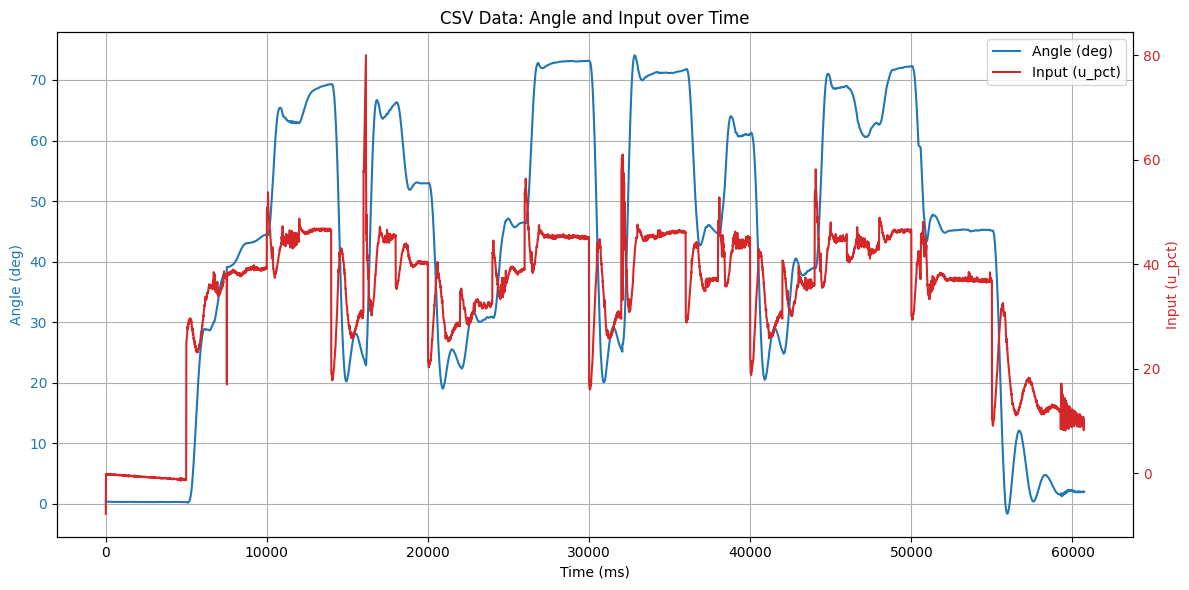

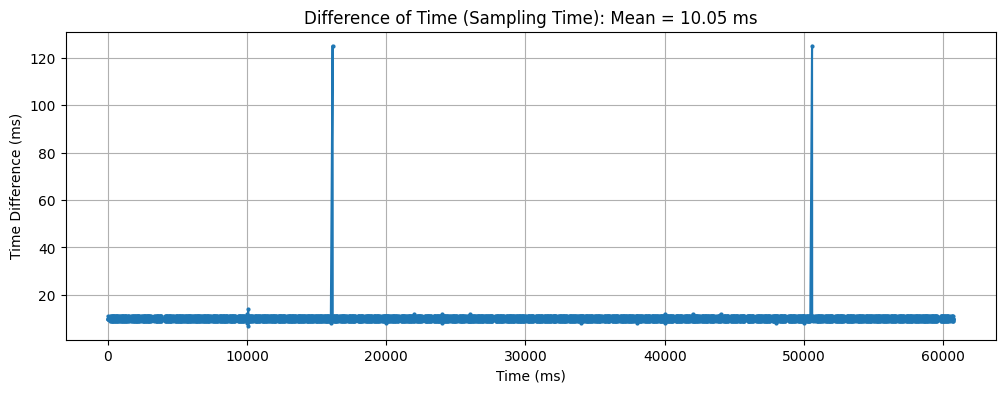

In [ ]:
import pandas as pd
import numpy as np

# New function to load CSV data
def load_csv_data(filepath):
    """
    Loads data from a CSV file.
    Assumes the CSV has columns 'Time', 'Input', 'Output'.
    """
    try:
        df = pd.read_csv(filepath)
        # Corrected column names based on available columns: ['tempo_ms', 'angulo_deg', 'u_pct', 'referencia']
        time_data = df['tempo_ms'].values
        u_data = df['u_pct'].values
        y_data = df['angulo_deg'].values
        print(f"Successfully loaded data from {filepath}")
        return time_data, u_data, y_data
    except FileNotFoundError:
        print(f"Error: CSV file not found at {filepath}")
        return np.array([]), np.array([]), np.array([])
    except KeyError as e:
        print(f"Error: Column {e} not found in the CSV file {filepath}. "
              "Please check the column names in your CSV.")
        print(f"Available columns: {df.columns.tolist()}")
        return np.array([]), np.array([]), np.array([])
    except Exception as e:
        print(f"An unexpected error occurred while loading CSV: {e}")
        return np.array([]), np.array([]), np.array([])

# Replace the randomStepSequence.mat loading with CSV data
csv_filepath = 'https://raw.githubusercontent.com/helonayala/sysid/main/data/14_drone_seq_20260529_195254.csv'
timee, ue, ye = load_csv_data(csv_filepath)

# Plotting the loaded CSV data with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(timee, ye, label='Angle (deg)', color='tab:blue')
ax1.set_ylabel('Angle (deg)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('CSV Data: Angle and Input over Time')
ax1.set_xlabel('Time (ms)')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(timee, ue, label='Input (u_pct)', color='tab:red')
ax2.set_ylabel('Input (u_pct)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# Plotting the difference of 'timee' to check sampling time
plt.figure(figsize=(12, 4))
timee_diff = np.diff(timee)
mean_timee_diff = np.mean(timee_diff) # Calculate mean here
plt.plot(timee[1:], timee_diff, 'o-', markersize=2)
plt.title(f'Difference of Time (Sampling Time): Mean = {mean_timee_diff:.2f} ms') # Use mean in title
plt.xlabel('Time (ms)')
plt.ylabel('Time Difference (ms)')
plt.grid(True)
plt.show()

### Processed CSV Data: Slicing and Decimation

Original data length: 6039
Requested time range: [4000ms, 50000ms]
Sliced data length: 4581 (from 4008ms to 49998ms)
Decimated data length (factor 5): 917


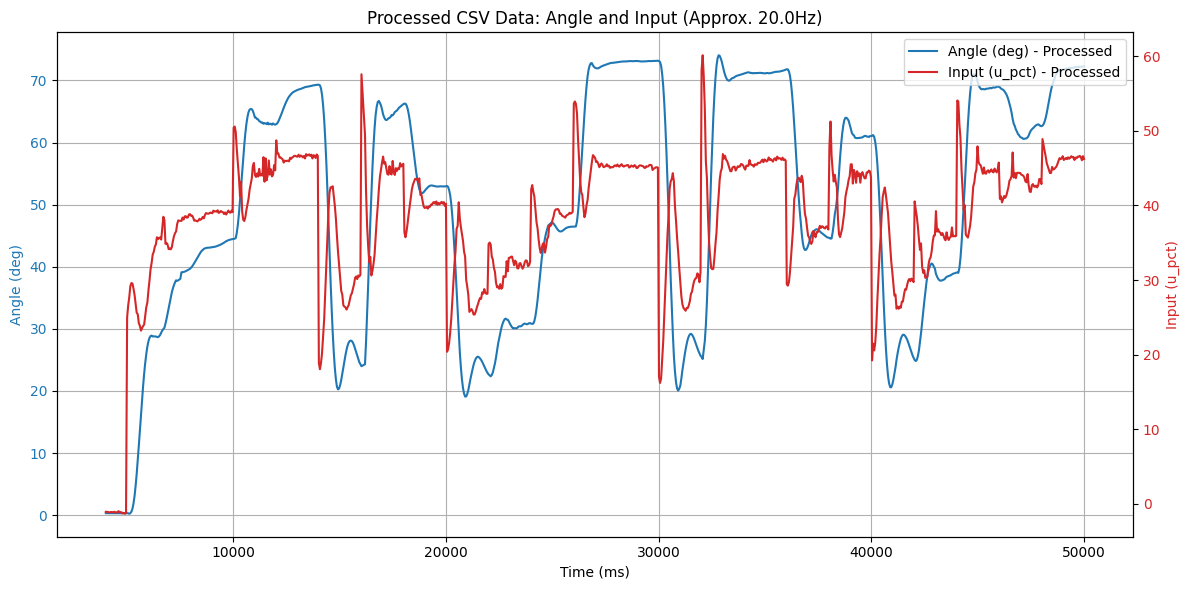

In [ ]:
# 1. Slice the vectors from a specified time range

start_time_ms = 4000
end_time_ms = 50000

# User-defined decimation factor
decimation_factor = 5 # Set this to 2, 5, 10, etc.

# Find indices for slicing
start_idx = np.searchsorted(timee, start_time_ms)
end_idx = np.searchsorted(timee, end_time_ms)

# Ensure indices are within bounds and adjust for inclusive end time
if start_idx >= len(timee): start_idx = len(timee) - 1
if end_idx >= len(timee): end_idx = len(timee) - 1
if timee[end_idx] > end_time_ms and end_idx > 0:
    end_idx -= 1

# Handle cases where the requested range is invalid or empty
if start_idx > end_idx:
    print(f"Warning: The requested time range [{start_time_ms}ms, {end_time_ms}ms] "
          f"is outside the available data range [{timee[0]}ms, {timee[-1]}ms].")
    print("Returning empty arrays for t, u, y.")
    t, u, y = np.array([]), np.array([]), np.array([])
else:
    # Slice the data
    timee_sliced = timee[start_idx : end_idx + 1]
    ue_sliced = ue[start_idx : end_idx + 1]
    ye_sliced = ye[start_idx : end_idx + 1]

    # Decimate the sliced data directly into t, u, y
    t = timee_sliced[::decimation_factor]
    u = ue_sliced[::decimation_factor]
    y = ye_sliced[::decimation_factor]

    print(f"Original data length: {len(timee)}")
    print(f"Requested time range: [{start_time_ms}ms, {end_time_ms}ms]")
    print(f"Sliced data length: {len(timee_sliced)} (from {timee_sliced[0]}ms to {timee_sliced[-1]}ms)")
    print(f"Decimated data length (factor {decimation_factor}): {len(t)}")


# 2. Plot the processed (sliced and decimated) data using t, u, y
fig, ax1 = plt.subplots(figsize=(12, 6))

if t.size > 0:
    ax1.plot(t, y, label='Angle (deg) - Processed', color='tab:blue')
    ax1.set_ylabel('Angle (deg)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    original_sampling_freq = 100 # Hz (approx 10ms per sample for original CSV)
    decimated_sampling_freq = original_sampling_freq / decimation_factor
    ax1.set_title(f'Processed CSV Data: Angle and Input (Approx. {decimated_sampling_freq:.1f}Hz)')
    ax1.set_xlabel('Time (ms)')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(t, u, label='Input (u_pct) - Processed', color='tab:red')
    ax2.set_ylabel('Input (u_pct)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')
else:
    ax1.set_title('No data to plot after slicing and decimation')
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Value')

plt.tight_layout()
plt.show()

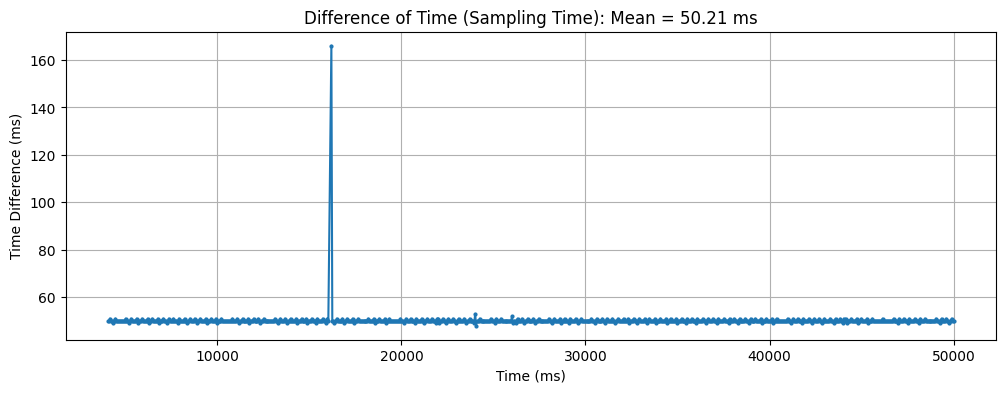

In [ ]:
plt.figure(figsize=(12, 4))
t_diff = np.diff(t)
mean_sampling_time = np.mean(t_diff)
plt.plot(t[1:], t_diff, 'o-', markersize=2)
plt.title(f'Difference of Time (Sampling Time): Mean = {mean_sampling_time:.2f} ms')
plt.xlabel('Time (ms)')
plt.ylabel('Time Difference (ms)')
plt.grid(True)
plt.show()

## Define model parameters, call constructor, and run estimation

In [ ]:
no_of_terms = 5
nu_model = 5
ny_model = 5
poly_order_model = 3

# 3. Instantiate and fit the NARX model
narx_model = NARX(nu=nu_model, ny=ny_model, poly_order_l=poly_order_model, selection_criteria=no_of_terms)
narx_model.fit(u, y)

print("--- Fitted NARX Model ---")
if narx_model.theta_ is not None and len(narx_model.theta_) > 0:
    print(f"Max lag internal (_max_lag_internal_): {narx_model._max_lag_internal_}")
    print("\nSelected terms & parameters (theta):")
    for i, term_name in enumerate(narx_model.selected_P_colnames_):
        print(f"  {i+1}. {term_name}: {narx_model.theta_[i]:.4f}")

    print("\nERR values for selected terms (%):")
    if narx_model.fit_results_['ERR_values'].size > 0:
        for i, err_val in enumerate(narx_model.fit_results_['ERR_values']):
            term_name = narx_model.selected_P_colnames_[i]
            print(f"  {term_name}: {err_val * 100:.10f}%")
    total_err_reduction = np.sum(narx_model.fit_results_['ERR_values']) * 100
    print(f"\nTotal ERR explained by selected terms: {total_err_reduction:.10f}%")
else:
    print("No terms were selected by FROLS, or fitting failed.")


--- Fitted NARX Model ---
Max lag internal (_max_lag_internal_): 5

Selected terms & parameters (theta):
  1. y(k-1): 1.9373
  2. y(k-2): -0.9545
  3. u(k-2)u(k-2): 0.0007
  4. u(k-4)u(k-5)u(k-5): 0.0000
  5. u(k-2)u(k-3): -0.0004

ERR values for selected terms (%):
  y(k-1): 99.9446113078%
  y(k-2): 0.0523169787%
  u(k-2)u(k-2): 0.0019806010%
  u(k-4)u(k-5)u(k-5): 0.0001481154%
  u(k-2)u(k-3): 0.0000362478%

Total ERR explained by selected terms: 99.9990932507%


## Free-Run (FR) Simulation

In [ ]:
max_lag = narx_model._max_lag_internal_

# estimation, not so difficult
ye_fr = y[max_lag:] # Target for the FR part
ye_hat = narx_model.predict(u, y_history_for_lags_or_osa=ye[:max_lag], mode='FR')


Starting Free-Run Simulation for 912 steps...


FR Simulation:   0%|          | 0/912 [00:00<?, ?step/s]

### Sampling time of the NARX model

In [ ]:
sampling_time_ms = (1 / original_sampling_freq) * 1000 * decimation_factor
print(f"The sampling time used to create the NARX model is {sampling_time_ms:.2f} ms.")

The sampling time used to create the NARX model is 50.00 ms.


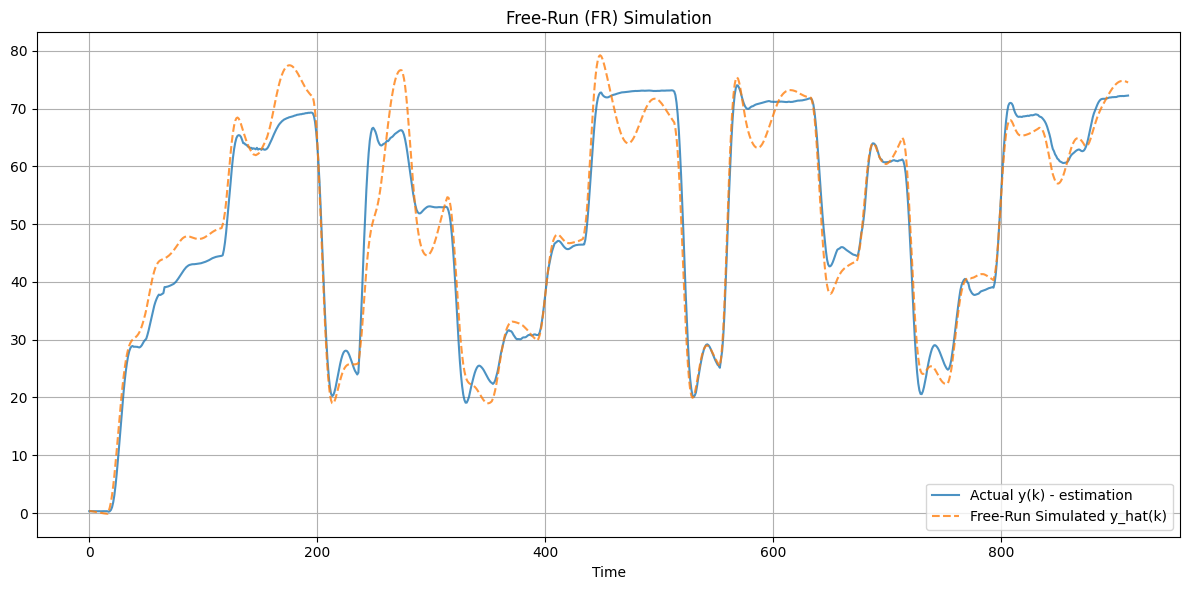

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ye_fr, label='Actual y(k) - estimation', alpha=0.8)
plt.plot(ye_hat, label='Free-Run Simulated y_hat(k)', linestyle='--', alpha=0.8)
plt.title(f'Free-Run (FR) Simulation')
plt.xlabel(f'Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
